<a href="https://colab.research.google.com/github/RosaCastillo10/Practica-5---LabPDI/blob/main/P5_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Parte I - Transformaciones geométricas***

**Introducción**

En esta práctica se aplican diferentes transformaciones geométricas a imágenes digitales utilizando Python y librerías como OpenCV, NumPy y Matplotlib. Se analizarán distintos tipos de traslaciones, así como combinaciones con rotación, escalado y transformaciones más avanzadas como la afín y radial.

**Ejercicio 1: Traslación básica**

Se aplica una traslación de la imagen de 50 píxeles en X y 30 píxeles en Y.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Subir imagen desde tu computadora
from google.colab import files
files.upload()

# Cargar imagen
imagen = cv2.imread('imagen1.jpg', cv2.IMREAD_GRAYSCALE)

# Verificar
if imagen is None:
    print("Error cargando imagen")
else:
    print("Imagen cargada correctamente")

alto, ancho = imagen.shape

Saving imagen1.jpg to imagen1.jpg
Imagen cargada correctamente


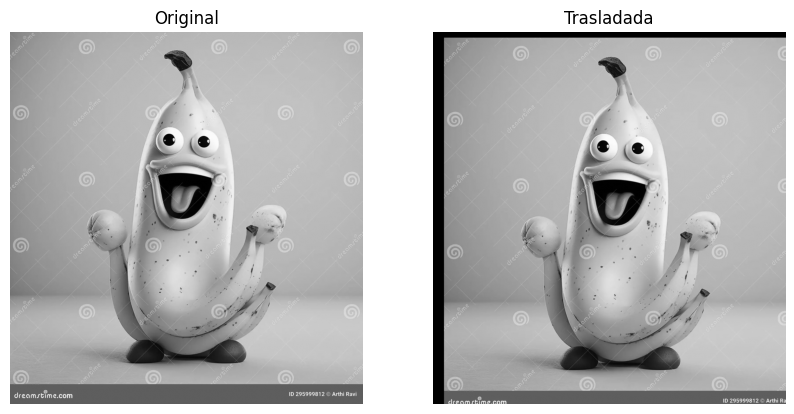

In [2]:
tx, ty = 50, 30

M = np.float32([[1, 0, tx],
                [0, 1, ty]])

imagen_trasladada = cv2.warpAffine(imagen, M, (ancho, alto))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imagen, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_trasladada, cmap='gray')
plt.title("Trasladada")
plt.axis("off")

plt.show()


**Ejercicio 2: Traslación con decimales**

Se aplica una traslación con valores decimales (20.5, 15.5) y se compara con la traslación entera.


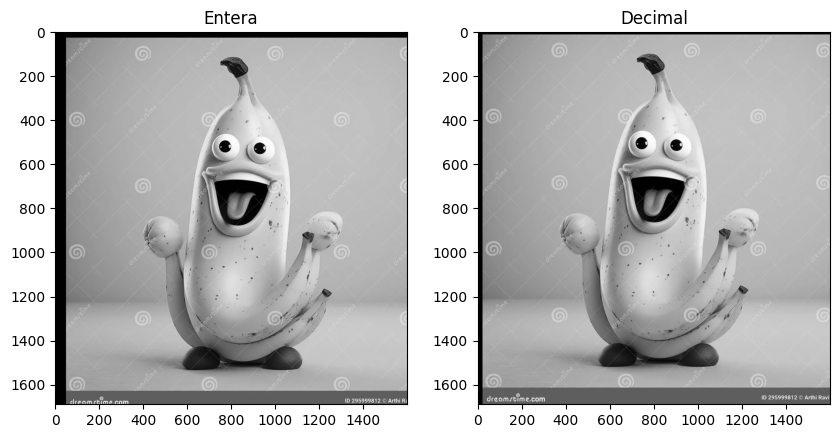

In [3]:
# Entera
M1 = np.float32([[1, 0, 50],
                 [0, 1, 30]])

img_entera = cv2.warpAffine(imagen, M1, (ancho, alto))

# Decimal
M2 = np.float32([[1, 0, 20.5],
                 [0, 1, 15.5]])

img_decimal = cv2.warpAffine(imagen, M2, (ancho, alto))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_entera, cmap='gray')
plt.title("Entera")

plt.subplot(1,2,2)
plt.imshow(img_decimal, cmap='gray')
plt.title("Decimal")

plt.show()

**Ejercicio 3: Traslación + Rotación**

Se aplica primero una traslación y posteriormente una rotación de 45 grados.

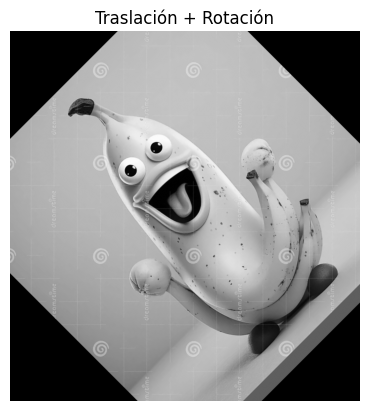

In [4]:
# Traslación
M = np.float32([[1, 0, 50],
                [0, 1, 30]])

img_trans = cv2.warpAffine(imagen, M, (ancho, alto))

# Rotación
(h, w) = img_trans.shape
centro = (w//2, h//2)

M_rot = cv2.getRotationMatrix2D(centro, 45, 1)

img_rotada = cv2.warpAffine(img_trans, M_rot, (w, h))

plt.imshow(img_rotada, cmap='gray')
plt.title("Traslación + Rotación")
plt.axis("off")
plt.show()

**Ejercicio 4: Traslación + Rotación + Escalado**

Se combinan traslación, rotación y escalado usando factores menores y mayores al 100%.

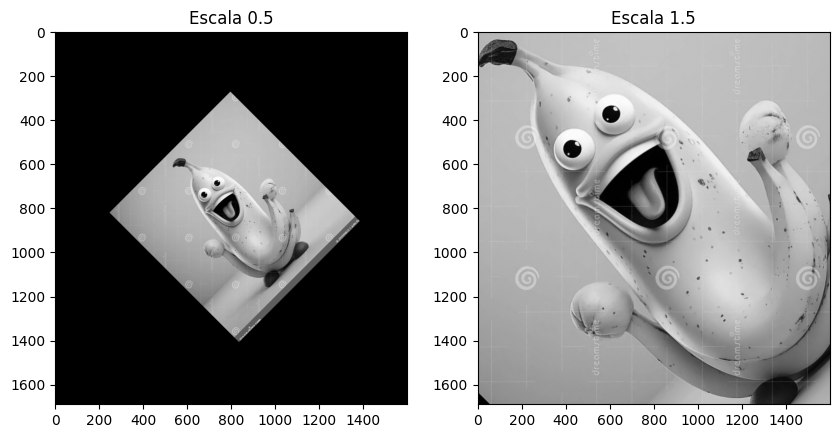

In [5]:
# Traslación
M = np.float32([[1, 0, 50],
                [0, 1, 30]])

img_trans = cv2.warpAffine(imagen, M, (ancho, alto))

(h, w) = img_trans.shape
centro = (w//2, h//2)

# Escala menor
M1 = cv2.getRotationMatrix2D(centro, 45, 0.5)
img_small = cv2.warpAffine(img_trans, M1, (w, h))

# Escala mayor
M2 = cv2.getRotationMatrix2D(centro, 45, 1.5)
img_big = cv2.warpAffine(img_trans, M2, (w, h))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_small, cmap='gray')
plt.title("Escala 0.5")

plt.subplot(1,2,2)
plt.imshow(img_big, cmap='gray')
plt.title("Escala 1.5")

plt.show()

**Ejercicio 5: Transformación Afín y Radial**

Se aplica una transformación afín mediante puntos de referencia y una distorsión tipo radial.

***Afín***

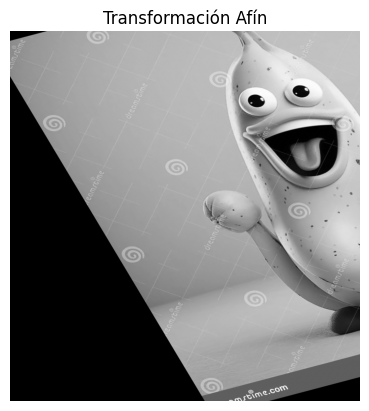

In [6]:
pts1 = np.float32([[50,50], [200,50], [50,200]])
pts2 = np.float32([[10,100], [200,50], [100,250]])

M = cv2.getAffineTransform(pts1, pts2)

img_afin = cv2.warpAffine(imagen, M, (ancho, alto))

plt.imshow(img_afin, cmap='gray')
plt.title("Transformación Afín")
plt.axis("off")
plt.show()

***Radial***

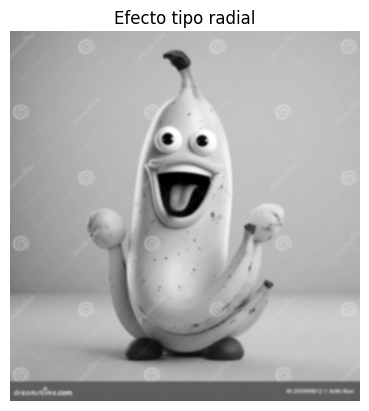

In [7]:
img_radial = cv2.GaussianBlur(imagen, (25,25), 0)

plt.imshow(img_radial, cmap='gray')
plt.title("Efecto tipo radial")
plt.axis("off")
plt.show()

***Parte II - Preguntas***

*   **Pregunta 1**

¿Qué diferencias observaste entre traslaciones enteras y con decimales?

*Las traslaciones enteras desplazan la imagen en cantidades exactas de píxeles, lo que mantiene la estructura original sin alteraciones en la calidad visual. Por otro lado, las traslaciones con valores decimales requieren interpolación para calcular los nuevos valores de los píxeles, lo que puede generar una imagen ligeramente más suave o difusa. En resumen, las traslaciones enteras son más precisas, mientras que las decimales producen una transición más continua pero con posible pérdida de nitidez.*

*   **Pregunta 2**

¿Qué ventaja tiene combinar traslación con rotación y escalado en el análisis de imágenes?

*La combinación de traslación, rotación y escalado permite manipular imágenes de forma más completa, facilitando su análisis desde diferentes perspectivas. Estas transformaciones ayudan a alinear objetos, ajustar su tamaño y corregir su orientación, lo cual es especialmente útil en aplicaciones como el reconocimiento de patrones, procesamiento de imágenes médicas y visión por computadora. Gracias a esta combinación, se puede mejorar la interpretación y comparación de imágenes.*

*   **Pregunta 3**

¿En qué aplicaciones prácticas podrían utilizarse las transformaciones afines o distorsiones radiales?

*Las transformaciones afines y las distorsiones radiales tienen múltiples aplicaciones prácticas. En el área médica, se utilizan para corregir deformaciones en imágenes como radiografías o resonancias magnéticas. En visión por computadora, son útiles para el reconocimiento facial, detección de objetos y calibración de cámaras. Las distorsiones radiales también se emplean para corregir efectos de lentes, como el efecto de “ojo de pez”. En general, estas transformaciones permiten mejorar la calidad, precisión y análisis de imágenes digitales.*

***Conclusión***

Las transformaciones geométricas son herramientas fundamentales en el procesamiento digital de imágenes. Permiten modificar la posición, orientación y tamaño de una imagen, siendo ampliamente utilizadas en aplicaciones médicas e industriales.